In [4]:
#yfinance is a popular Python library used for downloading historical market data from Yahoo Finance.
#It simplifies the process of accessing financial data for various securities, including stocks, commodities, cryptocurrencies, and more

#!pip install yfinance

In [5]:
import seaborn as sns
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
#from sklearn import metrics
#from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
#The code fetches historical price data for Bitcoin, Ethereum, Tether, and Binance Coin for the past 5 years and keeps only the Close and Volume columns for each of these cryptocurrencies.
#This cleaned data can then be used for further analysis or machine learning tasks, such as predicting future prices.


btc = yf.Ticker('BTC-USD')
prices1 = btc.history(period='5y')
prices1.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

eth = yf.Ticker('ETH-USD')
prices2 = eth.history(period='5y')
prices2.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

usdt = yf.Ticker('USDT-USD')
prices3 = usdt.history(period='5y')
prices3.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

bnb = yf.Ticker('BNB-USD')
prices4 = bnb.history(period='5y')
prices4.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

In [7]:
#The parameters lsuffix and rsuffix in the join method are used to add suffixes to overlapping column names when joining two DataFrames
# This is necessary to avoid column name conflicts when the two DataFrames have columns with the same name.

p1 = prices1.join(prices2, lsuffix = ' (BTC)', rsuffix = ' (ETH)')
p2 = prices3.join(prices4, lsuffix = ' (USDT)', rsuffix = ' (BNB)')
data = p1.join(p2, lsuffix = '_', rsuffix = '_')

In [8]:
data.head()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2021-03-11 00:00:00+00:00,57805.121094,56772343595,1826.194946,24013132909,1.000583,93576067866,289.790802,4676132222
2021-03-12 00:00:00+00:00,57332.089844,55689944702,1772.102417,22435821312,1.000343,99392797660,263.685822,3960814749
2021-03-13 00:00:00+00:00,61243.085938,60669829814,1924.685425,25014689475,0.999845,105301861825,276.104706,2903774859
2021-03-14 00:00:00+00:00,59302.316406,43901225564,1854.564331,19344589211,0.999791,83527066354,264.636749,2044273970
2021-03-15 00:00:00+00:00,55907.199219,66419369890,1791.702271,26244738810,1.000374,110958014435,254.660828,2488528410


In [9]:
data.tail()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2026-03-07 00:00:00+00:00,67272.593750,23258701211,1969.455444,10236899078,0.999911,48114595839,620.066284,1082294510
2026-03-08 00:00:00+00:00,65969.781250,33195080116,1936.604736,16314032554,0.999929,64087330423,612.038879,1289759347
2026-03-09 00:00:00+00:00,68402.382812,49499875378,1992.938232,24015826480,1.000102,91625548383,634.500366,1626567950
2026-03-10 00:00:00+00:00,69926.921875,54003996096,2037.120483,23552353781,1.000115,96697987753,641.879211,1580638205
2026-03-11 00:00:00+00:00,69458.914062,47028645888,2021.912354,20305924096,1.000010,87391526912,637.098999,1512733568


In [10]:
data.shape

(1827, 8)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2021-03-11 00:00:00+00:00 to 2026-03-11 00:00:00+00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close (BTC)    1827 non-null   float64
 1   Volume (BTC)   1827 non-null   int64  
 2   Close (ETH)    1827 non-null   float64
 3   Volume (ETH)   1827 non-null   int64  
 4   Close (USDT)   1827 non-null   float64
 5   Volume (USDT)  1827 non-null   int64  
 6   Close (BNB)    1827 non-null   float64
 7   Volume (BNB)   1827 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 128.5 KB


In [12]:
data.isna().sum()

Close (BTC)      0
Volume (BTC)     0
Close (ETH)      0
Volume (ETH)     0
Close (USDT)     0
Volume (USDT)    0
Close (BNB)      0
Volume (BNB)     0
dtype: int64

In [13]:
data.describe()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
count,1827.000000,1.827000e+03,1827.000000,1.827000e+03,1827.000000,1.827000e+03,1827.000000,1.827000e+03
mean,55821.584429,3.620669e+10,2573.028494,1.916629e+10,1.000099,7.007808e+10,481.041789,1.818360e+09
std,29735.015582,2.119380e+10,891.326434,1.268376e+10,0.000713,4.455116e+10,217.971150,1.339817e+09
min,15787.284180,5.331173e+09,993.636780,2.081626e+09,0.995872,9.989859e+09,197.042999,2.038465e+08
25%,29412.204102,2.112790e+10,1823.524658,1.017214e+10,0.999845,4.007070e+10,299.315964,9.409490e+08
50%,48628.511719,3.160472e+10,2502.349609,1.631720e+10,1.000121,6.007752e+10,428.098328,1.618599e+09
75%,72870.097656,4.554204e+10,3243.557007,2.389577e+10,1.000356,8.653507e+10,613.649109,2.190866e+09
max,124752.531250,1.817464e+11,4831.348633,9.773662e+10,1.011530,3.443980e+11,1310.214355,1.443632e+10


#Exploratory Data Analysis

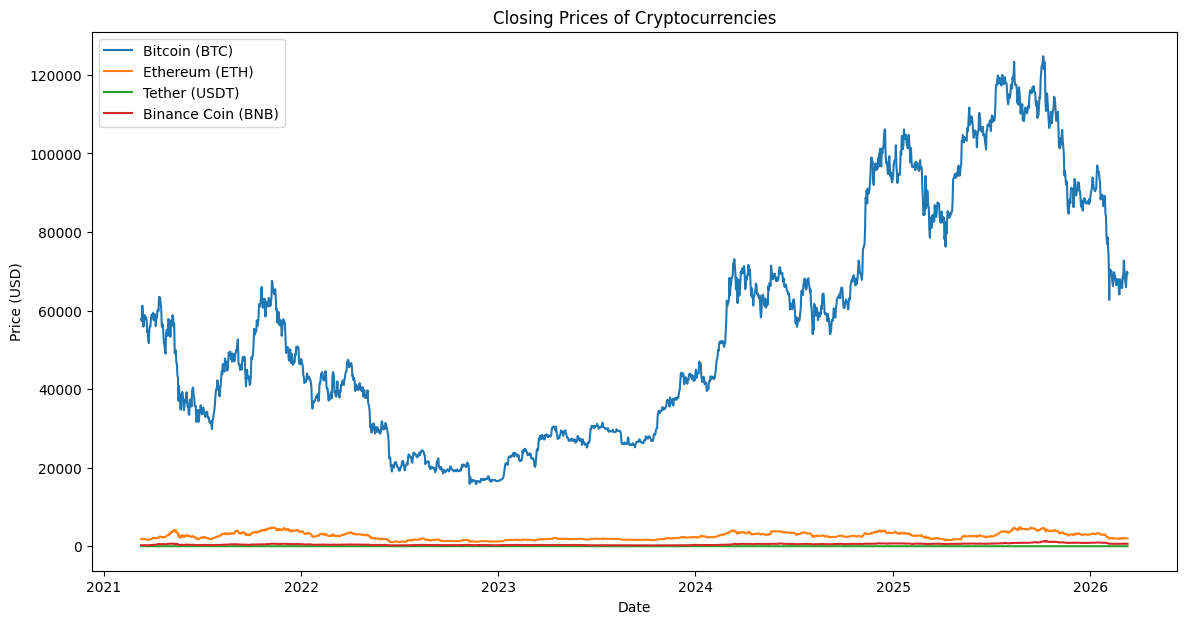

In [14]:
#Visualize the Closing Prices
# create a line plot to visualize the closing prices of all four cryptocurrencies over time:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close (BTC)'], label='Bitcoin (BTC)')
plt.plot(data.index, data['Close (ETH)'], label='Ethereum (ETH)')
plt.plot(data.index, data['Close (USDT)'], label='Tether (USDT)')
plt.plot(data.index, data['Close (BNB)'], label='Binance Coin (BNB)')
plt.title('Closing Prices of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


<Axes: xlabel='Date'>

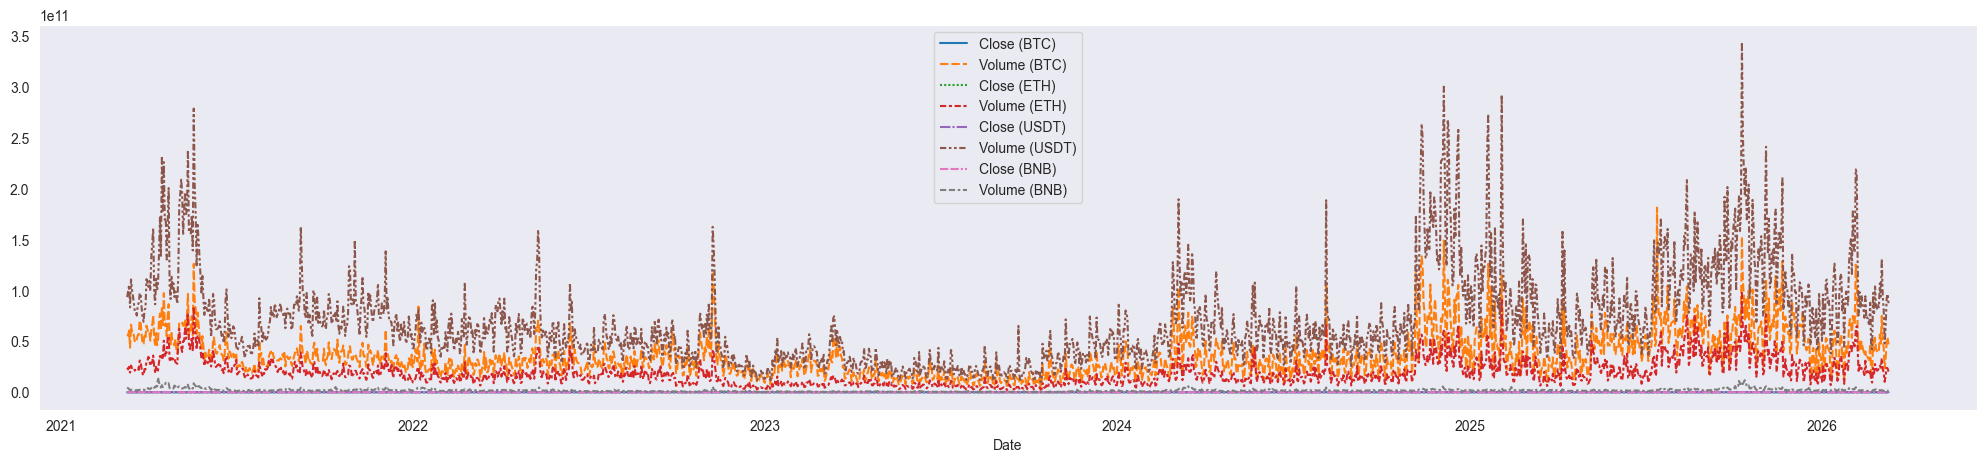

In [15]:
plt.figure(figsize = (25, 5))
sns.set_style('dark')
sns.lineplot(data=data)

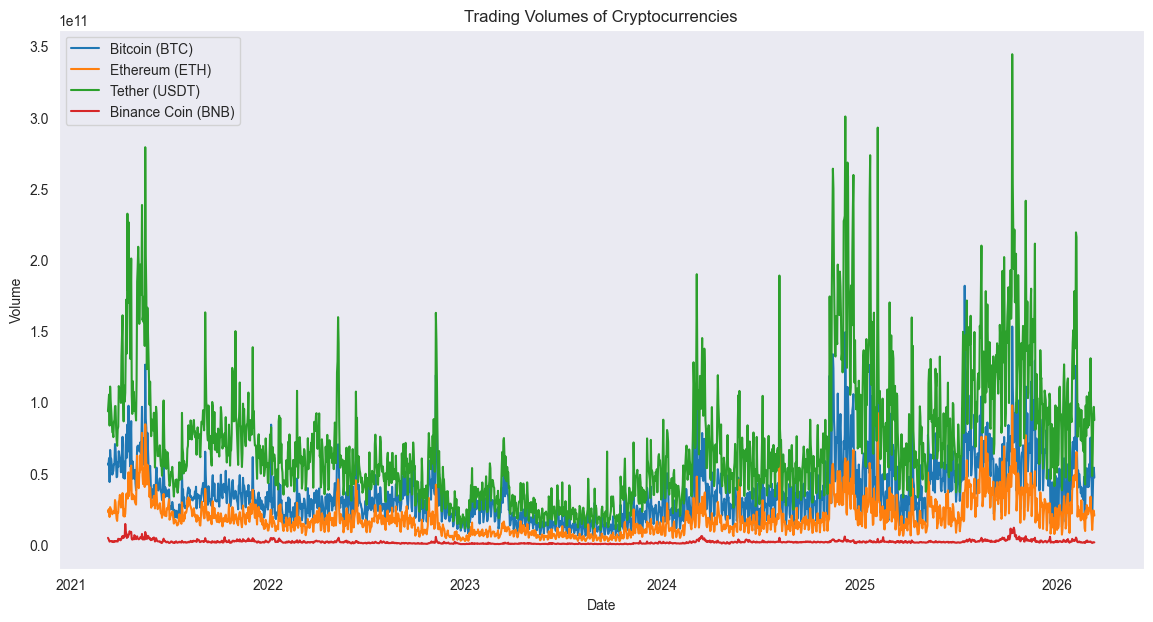

In [16]:
# Visualize the Trading Volumes
#Let's visualize the trading volumes of all four cryptocurrencies:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Volume (BTC)'], label='Bitcoin (BTC)')
plt.plot(data.index, data['Volume (ETH)'], label='Ethereum (ETH)')
plt.plot(data.index, data['Volume (USDT)'], label='Tether (USDT)')
plt.plot(data.index, data['Volume (BNB)'], label='Binance Coin (BNB)')
plt.title('Trading Volumes of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()


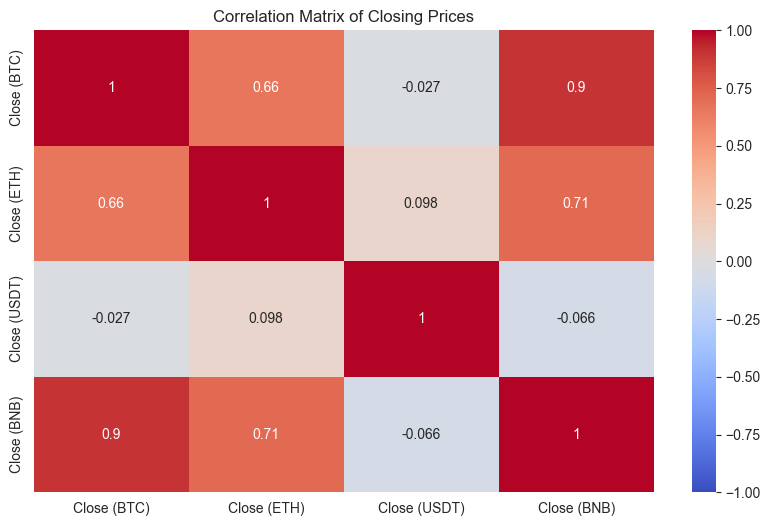

In [17]:
 #Correlation Analysis
#We'll analyze the correlation between the closing prices of the cryptocurrencies:
# Calculate the correlation matrix
corr_matrix = data[['Close (BTC)', 'Close (ETH)', 'Close (USDT)', 'Close (BNB)']].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Closing Prices')
plt.show()


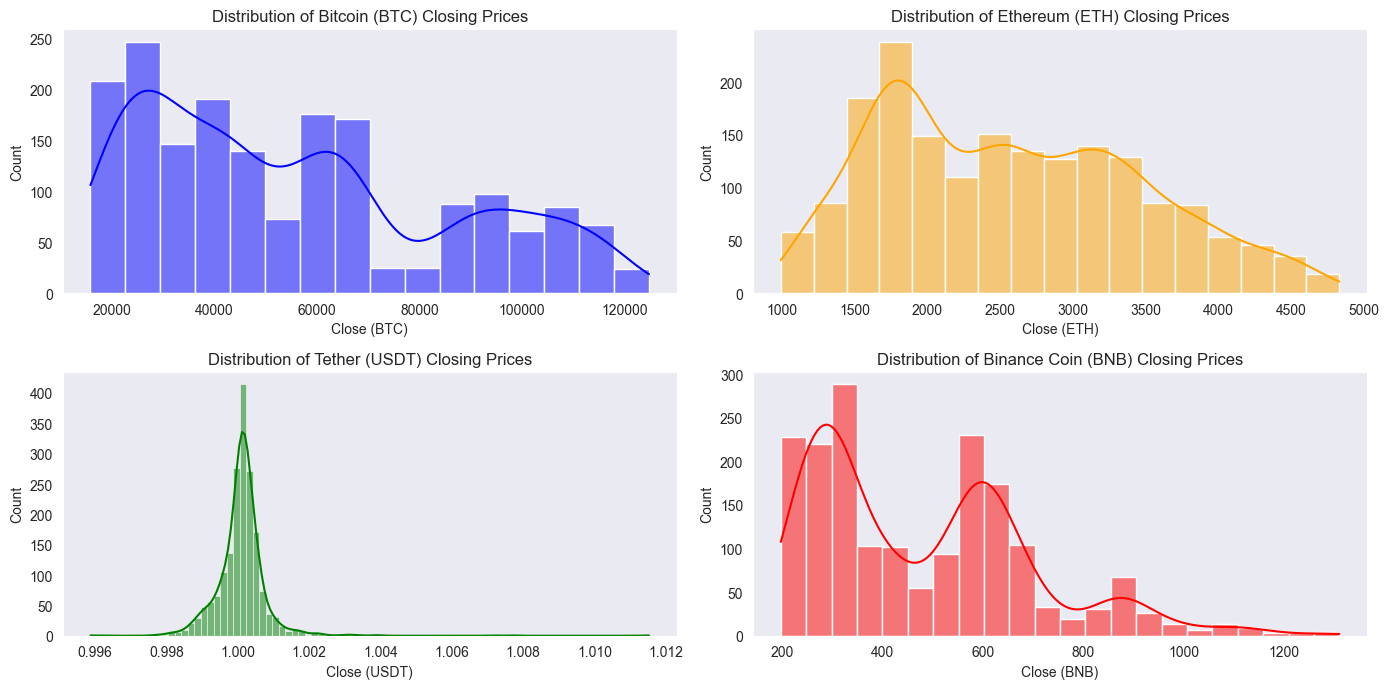

In [18]:
# Distribution of Closing Prices
#Let's plot the distribution of closing prices for each cryptocurrency:
plt.figure(figsize=(14, 7))

plt.subplot(2, 2, 1)
sns.histplot(data['Close (BTC)'], kde=True, color='blue')
plt.title('Distribution of Bitcoin (BTC) Closing Prices')

plt.subplot(2, 2, 2)
sns.histplot(data['Close (ETH)'], kde=True, color='orange')
plt.title('Distribution of Ethereum (ETH) Closing Prices')

plt.subplot(2, 2, 3)
sns.histplot(data['Close (USDT)'], kde=True, color='green')
plt.title('Distribution of Tether (USDT) Closing Prices')

plt.subplot(2, 2, 4)
sns.histplot(data['Close (BNB)'], kde=True, color='red')
plt.title('Distribution of Binance Coin (BNB) Closing Prices')

plt.tight_layout()
plt.show()


array([[<Axes: title={'center': 'Close (BTC)'}>,
        <Axes: title={'center': 'Volume (BTC)'}>,
        <Axes: title={'center': 'Close (ETH)'}>,
        <Axes: title={'center': 'Volume (ETH)'}>],
       [<Axes: title={'center': 'Close (USDT)'}>,
        <Axes: title={'center': 'Volume (USDT)'}>,
        <Axes: title={'center': 'Close (BNB)'}>,
        <Axes: title={'center': 'Volume (BNB)'}>]], dtype=object)

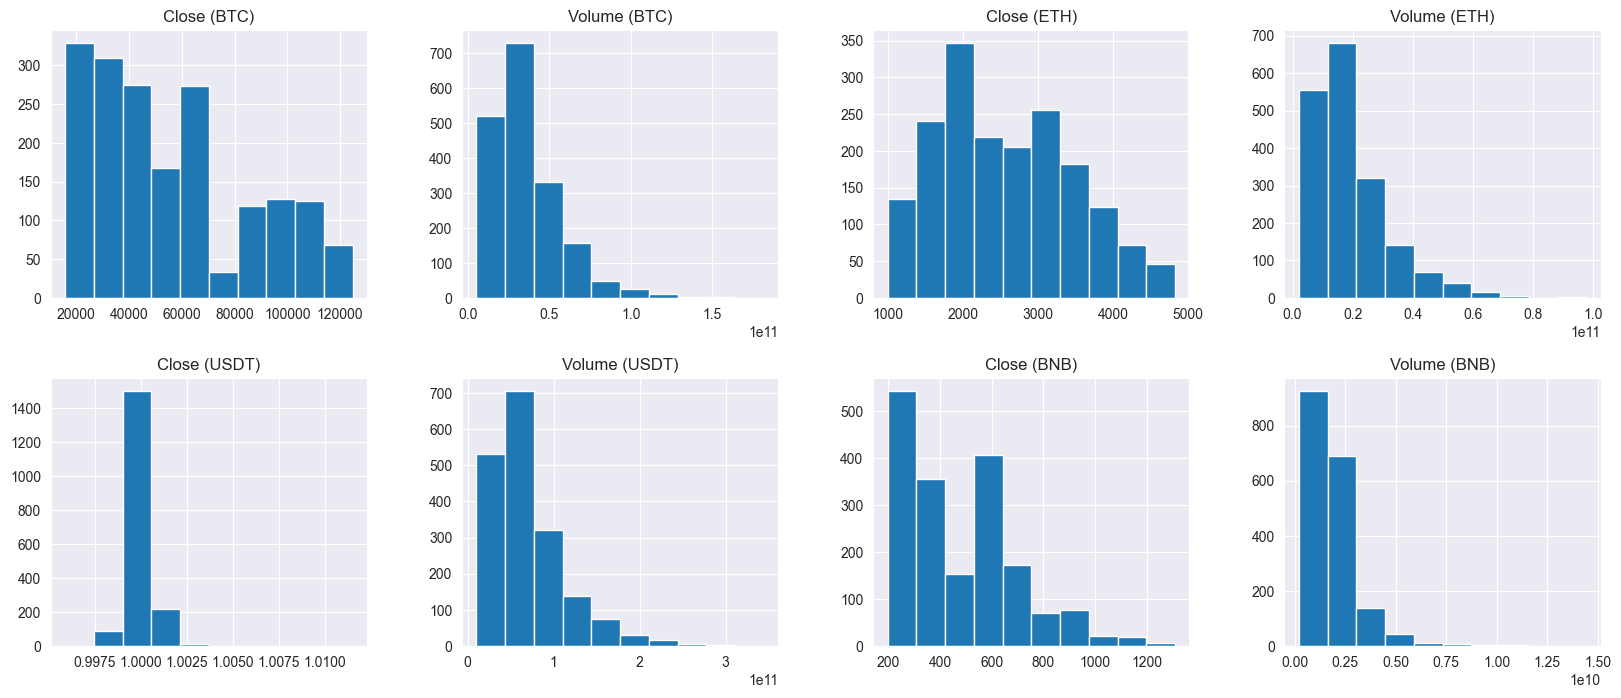

In [19]:
data.hist(figsize=(20, 8), layout=(2, 4))

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

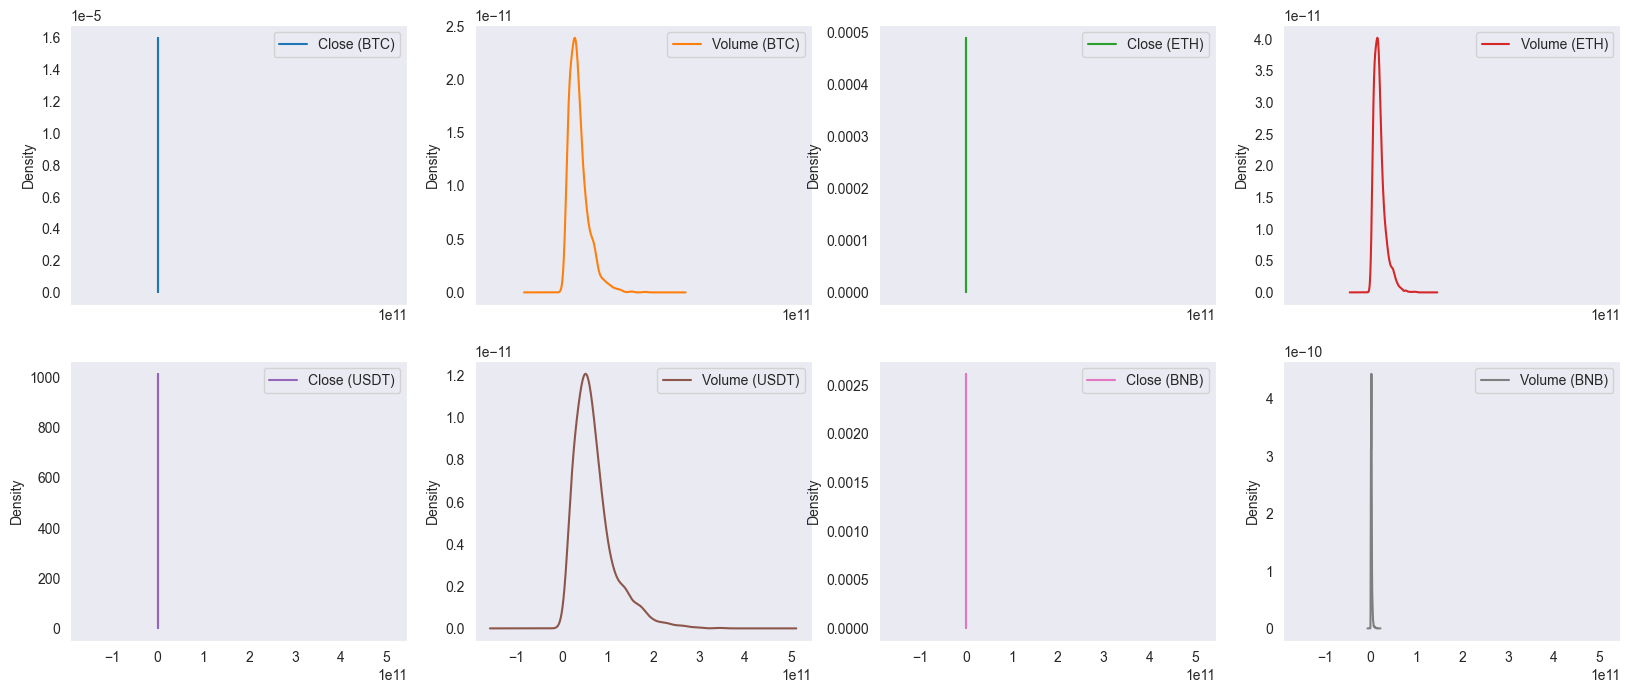

In [20]:
data.plot(kind = "kde", subplots = True, layout = (2, 4), figsize = (20, 8))

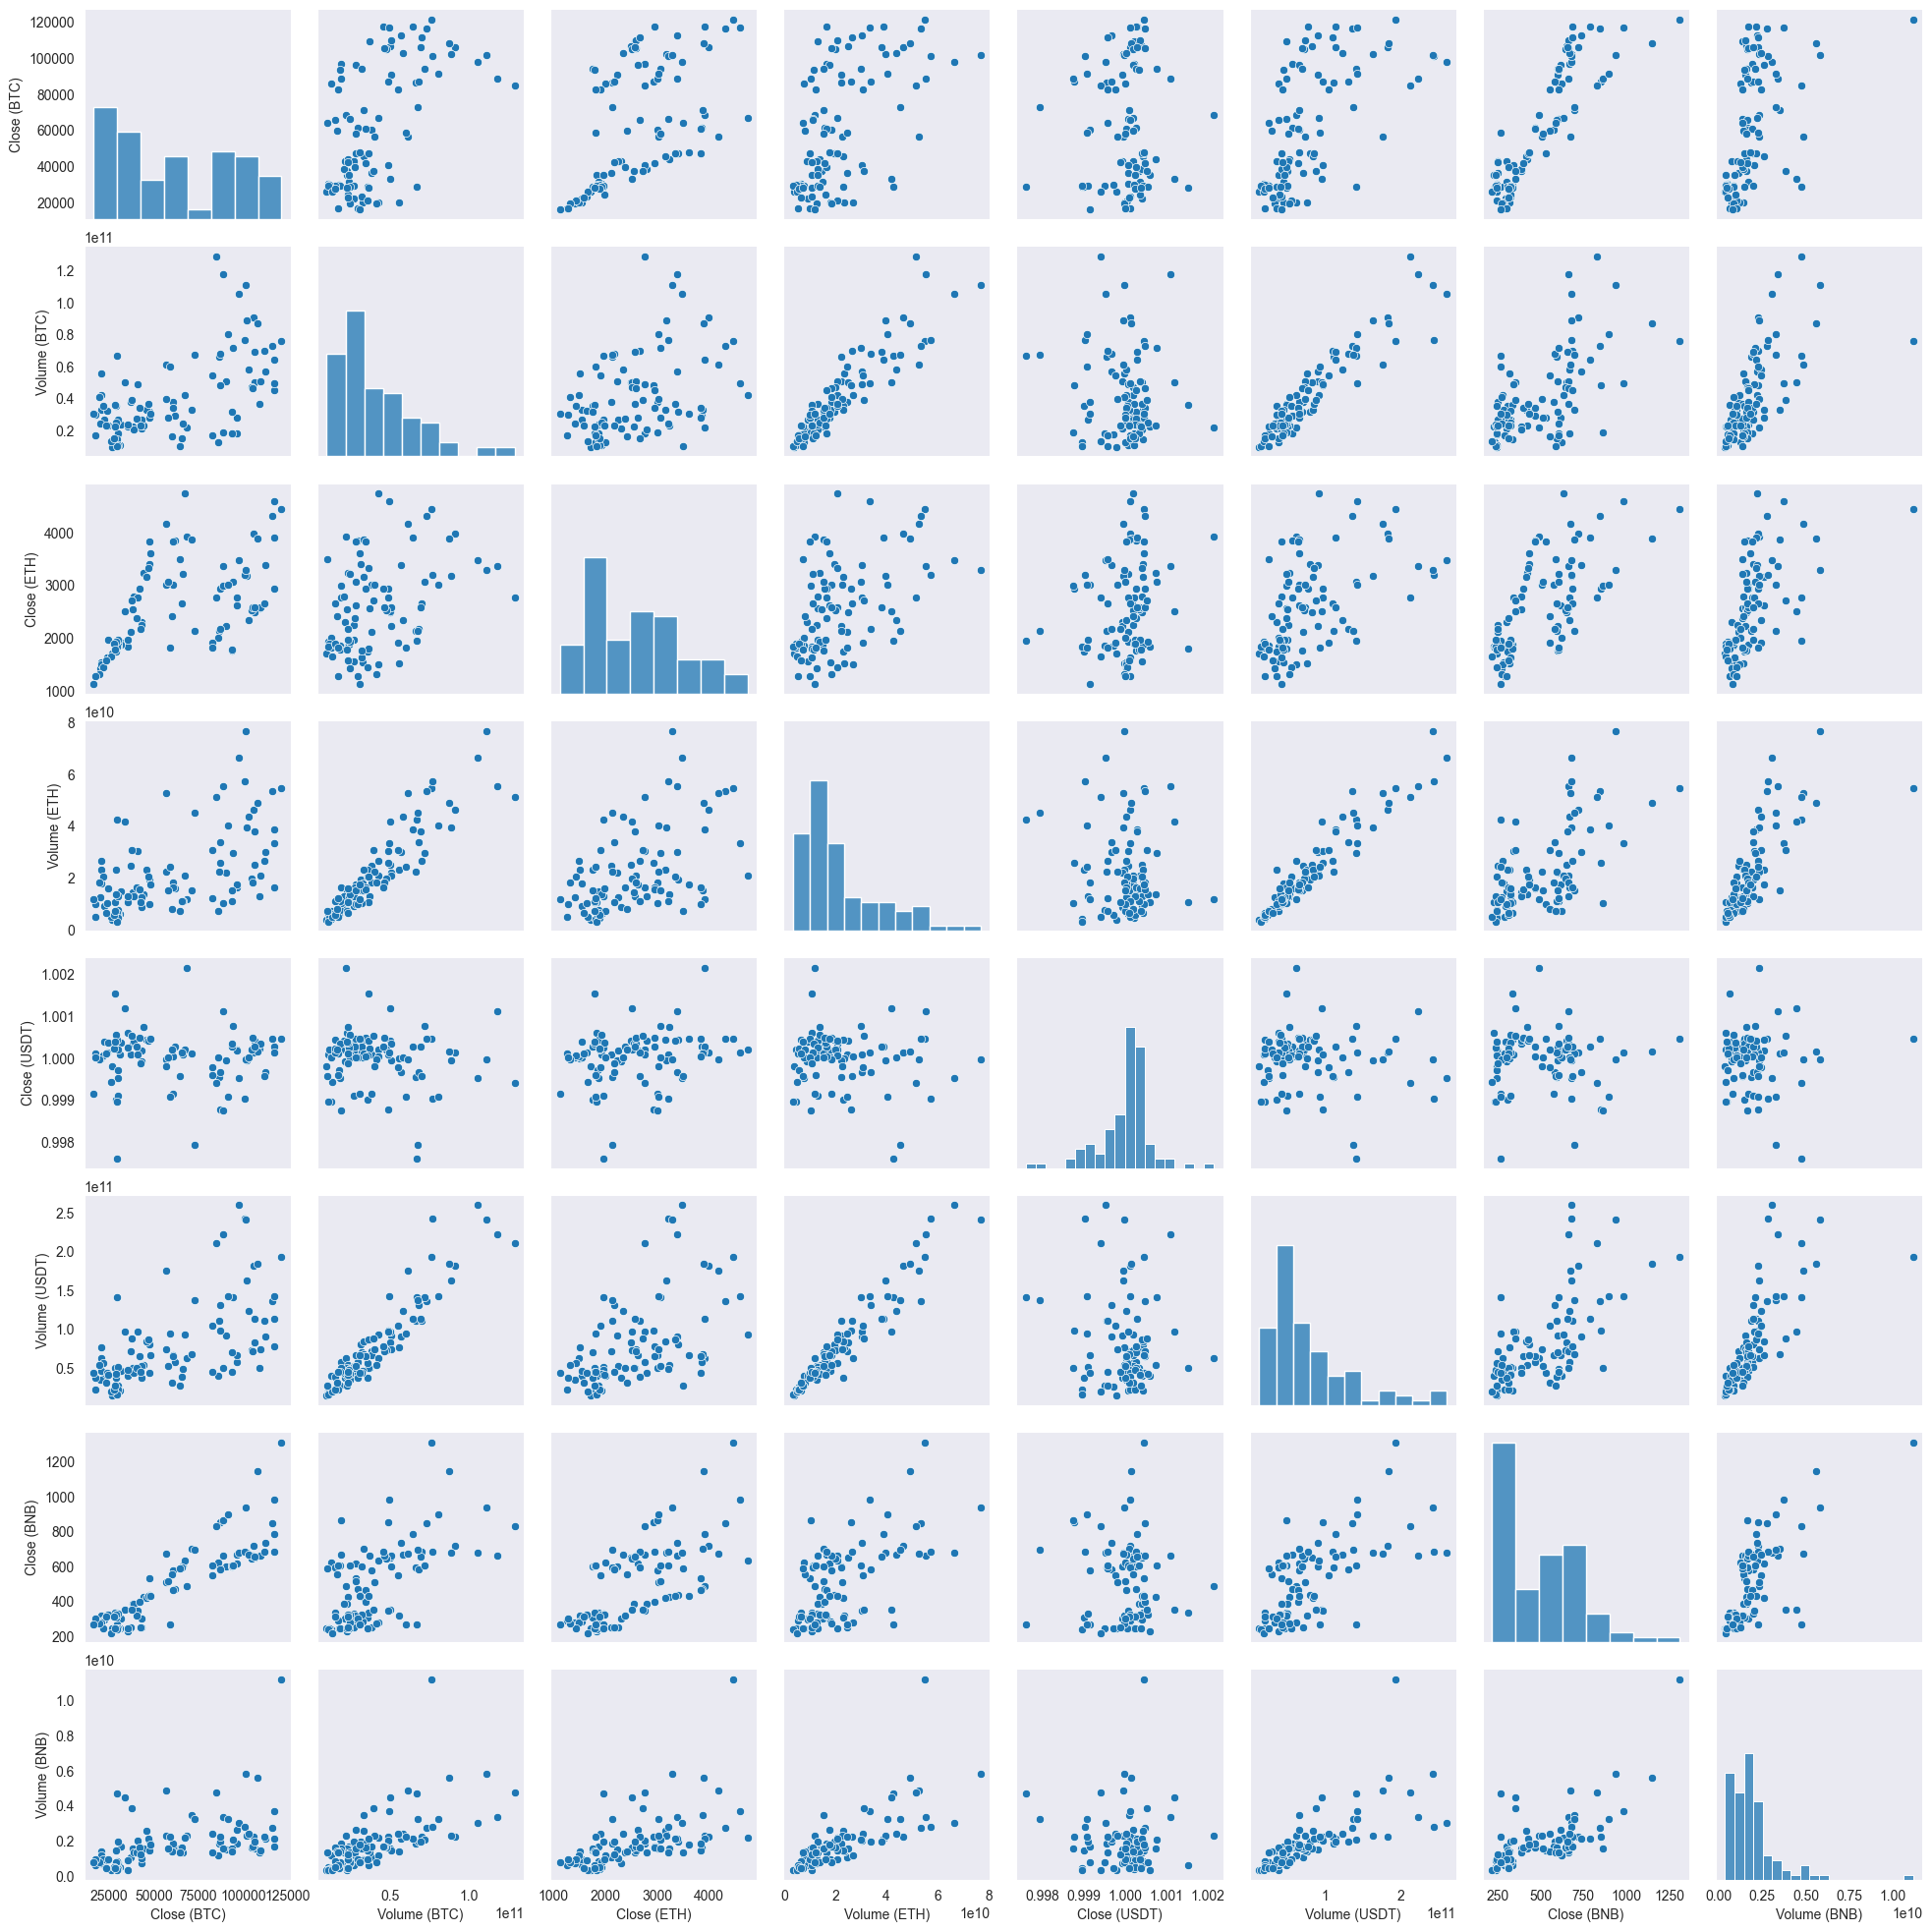

In [21]:
sns.pairplot(data.sample(n=100));

#Data Pre-processing

In [45]:
X = data.drop(columns = ['Close (BTC)'], axis = 1)
Y = data.loc[:, 'Close (BTC)']

In [46]:
X.head()

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2021-03-11 00:00:00+00:00,56772343595,1826.194946,24013132909,1.000583,93576067866,289.790802,4676132222
2021-03-12 00:00:00+00:00,55689944702,1772.102417,22435821312,1.000343,99392797660,263.685822,3960814749
2021-03-13 00:00:00+00:00,60669829814,1924.685425,25014689475,0.999845,105301861825,276.104706,2903774859
2021-03-14 00:00:00+00:00,43901225564,1854.564331,19344589211,0.999791,83527066354,264.636749,2044273970
2021-03-15 00:00:00+00:00,66419369890,1791.702271,26244738810,1.000374,110958014435,254.660828,2488528410


In [47]:
X.tail()

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2026-03-07 00:00:00+00:00,23258701211,1969.455444,10236899078,0.999911,48114595839,620.066284,1082294510
2026-03-08 00:00:00+00:00,33195080116,1936.604736,16314032554,0.999929,64087330423,612.038879,1289759347
2026-03-09 00:00:00+00:00,49499875378,1992.938232,24015826480,1.000102,91625548383,634.500366,1626567950
2026-03-10 00:00:00+00:00,54003996096,2037.120483,23552353781,1.000115,96697987753,641.879211,1580638205
2026-03-11 00:00:00+00:00,47028645888,2021.912354,20305924096,1.000010,87391526912,637.098999,1512733568


In [48]:
Y.head()

Date
2021-03-11 00:00:00+00:00    57805.121094
2021-03-12 00:00:00+00:00    57332.089844
2021-03-13 00:00:00+00:00    61243.085938
2021-03-14 00:00:00+00:00    59302.316406
2021-03-15 00:00:00+00:00    55907.199219
Name: Close (BTC), dtype: float64

In [26]:
# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [49]:
# Print the shapes of the resulting datasets
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {Y_train.shape}')
print(f'y_test shape: {Y_test.shape}')

X_train shape: (1461, 4)
X_test shape: (366, 4)
y_train shape: (1461,)
y_test shape: (366,)


In [35]:
#SelectKBest
#SelectKBest is a feature selection method provided by scikit-learn (sklearn) that selects the top k features based on a specified scoring function.
#This function evaluates each feature independently and selects those that have the strongest relationship with the target variable.

#Parameters
#k: Specifies the number of top features to select. In your case, k=4 indicates that you want to select the top 4 features

#from sklearn.feature_selection import SelectKBest

#fs = SelectKBest()


from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()

Xtrain = sc_X.fit_transform(X_train)

X_test = sc_X.transform(X_test) 




In [37]:
X_train


array([[0.46454366, 0.25029708, 0.35348647, 0.23633687],
       [0.368171  , 0.16949229, 0.2519837 , 0.07323715],
       [0.28405927, 0.10666999, 0.06762938, 0.04953249],
       ...,
       [0.39549709, 0.30556425, 0.70936557, 0.21710396],
       [0.35657077, 0.16019569, 0.06105961, 0.05995662],
       [0.36030302, 0.07412531, 0.09334301, 0.0480368 ]], shape=(1461, 4))

In [38]:
#MinMaxScaler is a preprocessing method in scikit-learn that transforms features by scaling them to a specified range.
# It's often used when your data needs to be normalized within a specific range to ensure all features contribute equally to the analysis.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
X_test

array([[ 0.08737866, -0.35134958,  0.14354847,  0.11918503],
       [-1.07903673, -0.40485353, -1.16645512, -0.28085005],
       [ 0.80878828,  0.0702876 ,  0.13933106,  0.33819964],
       ...,
       [ 0.67579396, -0.60720316, -0.73763791, -0.74860856],
       [-0.13961968, -0.86255215, -0.89284031, -1.09935762],
       [-0.72055739,  0.31745672,  0.94005556,  0.92167274]],
      shape=(366, 4))

In [42]:
Y_test

Date
2022-01-03 00:00:00+00:00    46458.117188
2022-07-13 00:00:00+00:00    20212.074219
2021-12-14 00:00:00+00:00    46612.632812
2023-05-15 00:00:00+00:00    27192.693359
2023-08-20 00:00:00+00:00    26189.583984
                                 ...     
2024-07-29 00:00:00+00:00    66819.914062
2021-08-29 00:00:00+00:00    48829.832031
2023-04-19 00:00:00+00:00    28822.679688
2023-03-07 00:00:00+00:00    22219.769531
2024-06-07 00:00:00+00:00    69342.585938
Name: Close (BTC), Length: 366, dtype: float64

In [43]:
# implementation of 10 different regression algorithms using scikit-learn. Each algorithm is trained and evaluated on a sample dataset:

#Import Libraries and Generate Sample Data

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

----- Linear Regression -----
Mean Squared Error (MSE): 15403181374.566673
R-squared: -17.027141526477067

----- Ridge Regression -----
Mean Squared Error (MSE): 14995783067.41592
R-squared: -16.550342171716473

----- Lasso Regression -----
Mean Squared Error (MSE): 15378633608.541042
R-squared: -16.998412003559576

----- ElasticNet Regression -----
Mean Squared Error (MSE): 326562172.10764366
R-squared: 0.6178073639060899

----- Support Vector Regression (SVR) -----
Mean Squared Error (MSE): 898197575.0520259
R-squared: -0.05120717665099206

----- Decision Tree Regression -----
Mean Squared Error (MSE): 310320091.5375769
R-squared: 0.6368163126421282

----- Random Forest Regression -----
Mean Squared Error (MSE): 221245123.23263365
R-squared: 0.7410653649029209

----- Gradient Boosting Regression -----
Mean Squared Error (MSE): 227479739.68535742
R-squared: 0.7337686701212744

----- K-Nearest Neighbors Regression -----
Mean Squared Error (MSE): 226353562.32423335
R-squared: 0.73508669

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


----- Neural Network Regression (MLP) -----
Mean Squared Error (MSE): 3767525106.333914
R-squared: -3.409329906910072

                             Model           MSE  R-squared
0                Linear Regression  1.540318e+10 -17.027142
1                 Ridge Regression  1.499578e+10 -16.550342
2                 Lasso Regression  1.537863e+10 -16.998412
3            ElasticNet Regression  3.265622e+08   0.617807
4  Support Vector Regression (SVR)  8.981976e+08  -0.051207
5         Decision Tree Regression  3.103201e+08   0.636816
6         Random Forest Regression  2.212451e+08   0.741065
7     Gradient Boosting Regression  2.274797e+08   0.733769
8   K-Nearest Neighbors Regression  2.263536e+08   0.735087
9  Neural Network Regression (MLP)  3.767525e+09  -3.409330


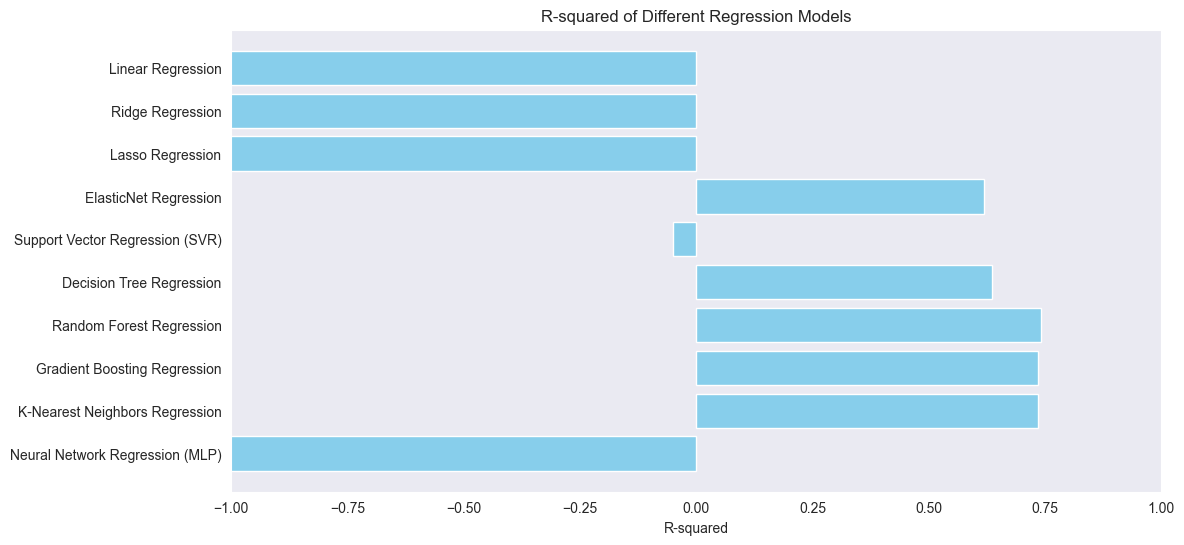

In [44]:

#Define Models and Perform Training and Evaluation
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'ElasticNet Regression': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Support Vector Regression (SVR)': SVR(kernel='rbf'),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(n_estimators=100),
    'Gradient Boosting Regression': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1),
    'K-Nearest Neighbors Regression': KNeighborsRegressor(n_neighbors=5),
    'Neural Network Regression (MLP)': MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam')
}

# Train and evaluate each model
results = {'Model': [], 'MSE': [], 'R-squared': []}

for name, model in models.items():
    # Train the model
    model.fit(X_train, Y_train)

    # Predict on test set
    Y_pred = model.predict(X_test)

    # Evaluate model
    mse = mean_squared_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)

    # Store results
    results['Model'].append(name)
    results['MSE'].append(mse)
    results['R-squared'].append(r2)

    # Print results
    print(f"----- {name} -----")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"R-squared: {r2}")
    print()

# Convert results to DataFrame for visualization
results_df = pd.DataFrame(results)
print(results_df)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.barh(results_df['Model'], results_df['R-squared'], color='skyblue')
plt.xlabel('R-squared')
plt.title('R-squared of Different Regression Models')
plt.xlim(-1, 1)
plt.gca().invert_yaxis()
plt.show()


#Random Forest Regression is a powerful and versatile algorithm suitable for various regression tasks, offering robust performance and the ability to handle complex data relationships

#Saving the Model


In [34]:
import pickle
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# Generate sample data
X, Y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=0)


# Scale the features (optional but recommended for some algorithms)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize Random Forest Regressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=0)

# Train the model
model_rf.fit(X_train, Y_train)

# Save the model to a file
filename = 'random_forest_model.pkl'
pickle.dump(model_rf, open(filename, 'wb'))

# Save scaler to a file
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Load the model from the file
loaded_model = pickle.load(open(filename, 'rb'))

# Predict using the loaded model
Y_pred = loaded_model.predict(X_test)

# Evaluate the loaded model
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Loaded Random Forest Regression - Mean Squared Error (MSE): {mse}")
print(f"Loaded Random Forest Regression - R-squared: {r2}")


Loaded Random Forest Regression - Mean Squared Error (MSE): 23513266.553700984
Loaded Random Forest Regression - R-squared: 0.926059783361375
